In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as T
import matplotlib.pyplot as plt
import copy
import pandas as pd
import numpy as np
import os
import seaborn as sns
import time
import random
from tqdm import tqdm
from pathlib import Path
from torch.utils.data import DataLoader, WeightedRandomSampler
from PIL import Image
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,confusion_matrix, classification_report)
from torchvision import models
from collections import Counter
from thop import profile

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
transform_train = T.Compose([
    T.RandomRotation(10, fill=[128, 128, 128]),
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_val = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [4]:
train_dataset = torchvision.datasets.ImageFolder(
    root="../../dataset/CK+_cropped/CK+_224x224/train",
    transform=transform_train
)

val_dataset = torchvision.datasets.ImageFolder(
    root="../../dataset/CK+_cropped/CK+_224x224/val",
    transform=transform_val
)

test_dataset = torchvision.datasets.ImageFolder(
    root="../../dataset/CK+_cropped/CK+_224x224/test",
    transform=transform_val
)

In [5]:
batch_size = 32

count_images = torch.tensor(np.bincount(train_dataset.targets, minlength=8), dtype=torch.float32)

class_weights = 1.0 / torch.sqrt(count_images)

sample_weights = [class_weights[label] for label in train_dataset.targets]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

trainloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    sampler=sampler,
    pin_memory=True,
    num_workers=0,
    persistent_workers=False,
    drop_last=False
)

valloader = DataLoader(
    val_dataset,
    batch_size=batch_size * 2,
    shuffle=False,
    pin_memory=True,
    num_workers=0,
    persistent_workers=False
)

testloader = DataLoader(
    test_dataset,
    batch_size=batch_size * 2,
    shuffle=False,
    pin_memory=True,
    num_workers=0,
    persistent_workers=False
)

In [6]:
class CKPlus_MobileNetV3Large(nn.Module):
    def __init__(self, num_class=8, freeze_backbone=False):
        super().__init__()

        self.backbone = models.mobilenet_v3_large(weights="IMAGENET1K_V2")

        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        in_features = self.backbone.classifier[-1].in_features

        self.backbone.classifier[-1] = nn.Linear(in_features, num_class)

    def forward(self, x):
        return self.backbone(x)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CKPlus_MobileNetV3Large(num_class=8, freeze_backbone=True)
model = model.to(device)
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)

In [7]:
if device.type == "cuda":
    print("Training with CUDA")
else:
    print("Training with CPU")

Training with CUDA


In [8]:
model_dir = Path("../../model/mobilenet_v3_large")
checkpoint_path = model_dir / "CKPlus_MobileNetV3Large_checkpoint.pth"
best_weights_path = model_dir / "CKPlus_MobileNetV3Large_best_weights.pth"

n_epochs = 200
early_stopping = 10
min_delta = 0.005

if checkpoint_path.exists():
    print(f"\033[94m[INFO]\033[0m Resuming training from {checkpoint_path}")

    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

    start_epoch = checkpoint["epoch"] + 1

    model.load_state_dict(checkpoint["model_state_dict"])

    if start_epoch > 5:
        print(f"\033[94m[INFO]\033[0m Continuing fine-tuning phase.")

        for param in model.backbone.parameters():
            param.requires_grad = True

        backbone_params = [p for n, p in model.backbone.named_parameters() if not n.startswith("classifier.")]

        fc_params = model.backbone.classifier[-1].parameters()

        optimizer = optim.AdamW(
            [
                {"params": backbone_params, "lr": 3e-5},
                {"params": fc_params, "lr": 3e-4}
            ],
            weight_decay=1e-4
        )

        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=25, eta_min=1e-6)

        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])

    else:
        print(f"\033[94m[INFO]\033[0m Continuing frozen phase.")

        optimizer = optim.AdamW(model.backbone.classifier[-1].parameters(), lr=3e-4, weight_decay=1e-4)

        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=5, eta_min=1e-6)

        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])

    best_macro_f1 = checkpoint['best_macro_f1']
    best_epoch = checkpoint['best_epoch']

    training_time = checkpoint['training_time']

    train_loss_hist = checkpoint['train_loss_hist']
    train_acc_hist = checkpoint['train_acc_hist']
    train_precision_hist = checkpoint['train_precision_hist']
    train_recall_hist = checkpoint['train_recall_hist']
    train_macro_f1_hist = checkpoint['train_macro_f1_hist']

    val_loss_hist = checkpoint['val_loss_hist']
    val_acc_hist = checkpoint['val_acc_hist']
    val_precision_hist = checkpoint['val_precision_hist']
    val_recall_hist = checkpoint['val_recall_hist']
    val_macro_f1_hist = checkpoint['val_macro_f1_hist']

    print(f"\033[94m[INFO]\033[0m Ready to continue from the {start_epoch} epoch.")

else:
    start_epoch = 0
    best_macro_f1 = -1
    best_weights = None
    best_epoch = -1

    training_time = 0.0

    train_loss_hist = []
    train_acc_hist = []
    train_precision_hist = []
    train_recall_hist = []
    train_macro_f1_hist = []

    val_loss_hist = []
    val_acc_hist = []
    val_precision_hist = []
    val_recall_hist = []
    val_macro_f1_hist = []

    optimizer = optim.AdamW(model.backbone.classifier[-1].parameters(), lr=3e-4, weight_decay=1e-4)

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=5, eta_min=1e-6)

    print("\033[91m[ERROR]\033[0m No checkpoint found\n")
    print("\033[94m[INFO]\033[0m Starting training from scratch")

try:
    for epoch in range(start_epoch, n_epochs):
        if epoch == 5 and start_epoch <= 5:
            print(f"\033[94m[INFO]\033[0m Unfreezing backbone for fine-tuning.")

            for param in model.backbone.parameters():
                param.requires_grad = True
            
            backbone_params = [p for n, p in model.backbone.named_parameters() if not n.startswith("classifier.")]
            
            fc_params = model.backbone.classifier[-1].parameters()
            
            optimizer = optim.AdamW(
                [
                    {"params": backbone_params, "lr": 3e-5},
                    {"params": fc_params, "lr": 3e-4}
                ],
                weight_decay=1e-4
            )
            
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=25, eta_min=1e-6)

        train_loss_total = 0.0
        train_samples = 0
        train_y_true_all, train_y_pred_all = [], []

        torch.cuda.synchronize()
        epoch_start = time.time()

        model.train()

        with tqdm(trainloader, unit="batch") as bar:
            bar.set_description(f"Epoch {epoch}")

            for X_batch, y_batch in bar:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                y_pred = model(X_batch)
                loss = loss_fn(y_pred, y_batch)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                predictions = torch.argmax(y_pred, dim=1)

                train_loss_total += loss.item() * X_batch.size(0)
                train_samples += X_batch.size(0)

                train_y_true_all.extend(y_batch.cpu().numpy())
                train_y_pred_all.extend(predictions.cpu().numpy())

                batch_acc = (predictions == y_batch).float().mean().item()

                bar.set_postfix(loss=loss.item(), acc=batch_acc)

        train_loss = train_loss_total / train_samples
        
        train_acc = accuracy_score(train_y_true_all, train_y_pred_all)
        train_precision = precision_score(train_y_true_all, train_y_pred_all, average="macro", zero_division=0)
        train_recall = recall_score(train_y_true_all, train_y_pred_all, average="macro", zero_division=0)
        train_macro_f1 = f1_score(train_y_true_all, train_y_pred_all, average="macro", zero_division=0)

        train_loss_hist.append(train_loss)
        train_acc_hist.append(train_acc)
        train_precision_hist.append(train_precision)
        train_recall_hist.append(train_recall)
        train_macro_f1_hist.append(train_macro_f1)

        model.eval()
        val_loss_total = 0.0
        val_samples = 0
        val_y_true_all, val_y_pred_all = [], []

        with torch.no_grad():
            for X_batch, y_batch in valloader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                y_pred = model(X_batch)
                loss = loss_fn(y_pred, y_batch)

                predictions = torch.argmax(y_pred, dim=1)
                
                val_loss_total += loss.item() * X_batch.size(0)
                val_samples += X_batch.size(0)
                
                val_y_true_all.extend(y_batch.cpu().numpy())
                val_y_pred_all.extend(predictions.cpu().numpy())

        val_loss = val_loss_total / val_samples

        val_acc = accuracy_score(val_y_true_all, val_y_pred_all)
        val_precision = precision_score(val_y_true_all, val_y_pred_all, average="macro", zero_division=0)
        val_recall = recall_score(val_y_true_all, val_y_pred_all, average="macro", zero_division=0)
        val_macro_f1 = f1_score(val_y_true_all, val_y_pred_all, average="macro", zero_division=0)

        val_loss_hist.append(val_loss)
        val_acc_hist.append(val_acc)
        val_precision_hist.append(val_precision)
        val_recall_hist.append(val_recall)
        val_macro_f1_hist.append(val_macro_f1)

        scheduler.step()

        torch.cuda.synchronize()
        epoch_end = time.time()

        training_time += epoch_end - epoch_start

        if val_macro_f1 > best_macro_f1 + min_delta:
            best_macro_f1 = val_macro_f1
            best_epoch = epoch
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(best_weights, best_weights_path)

            print(f"\033[94m[INFO]\033[0m Best Macro F1 with value {best_macro_f1 * 100:.4f} in the epoch {best_epoch}")

        checkpoint = {"epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_macro_f1": best_macro_f1,
            "best_epoch": best_epoch,
            "training_time": training_time,
            "train_loss_hist": train_loss_hist,
            "train_acc_hist": train_acc_hist,
            "train_precision_hist": train_precision_hist,
            "train_recall_hist": train_recall_hist,
            "train_macro_f1_hist": train_macro_f1_hist,
            "val_loss_hist": val_loss_hist,
            "val_acc_hist": val_acc_hist,
            "val_precision_hist": val_precision_hist,
            "val_recall_hist": val_recall_hist,
            "val_macro_f1_hist": val_macro_f1_hist}

        torch.save(checkpoint, checkpoint_path)

        if epoch >= 5 and (epoch - best_epoch >= early_stopping):
            break

        print(f"Epoch {epoch} | Validation Macro F1 = {val_macro_f1*100:.2f}% | Validation Loss = {val_loss:.2f} | Val Accuracy = {val_acc*100:.2f}%")

    print(f"\033[94m[INFO]\033[0m Best model saved with Macro F1 = {best_macro_f1*100:.4f}%")

except KeyboardInterrupt:
    print("\033[93m[WARNING]\033[0m Training stopped manually")

[ERROR] No checkpoint found

[INFO] Starting training from scratch


Epoch 0: 100%|██████████| 17/17 [00:01<00:00, 10.68batch/s, acc=0.25, loss=2.05] 


[INFO] Best Macro F1 with value 11.2368 in the epoch 0
Epoch 0 | Validation Macro F1 = 11.24% | Validation Loss = 1.97 | Val Accuracy = 38.24%


Epoch 1: 100%|██████████| 17/17 [00:01<00:00, 15.15batch/s, acc=0.25, loss=1.99] 


[INFO] Best Macro F1 with value 12.8422 in the epoch 1
Epoch 1 | Validation Macro F1 = 12.84% | Validation Loss = 1.93 | Val Accuracy = 42.65%


...

Epoch 39 | Validation Macro F1 = 71.73% | Validation Loss = 0.72 | Val Accuracy = 85.29%


Epoch 40: 100%|██████████| 17/17 [00:01<00:00,  9.52batch/s, acc=1, loss=0.527]    


Epoch 40 | Validation Macro F1 = 75.76% | Validation Loss = 0.72 | Val Accuracy = 88.24%


Epoch 41: 100%|██████████| 17/17 [00:01<00:00,  9.70batch/s, acc=1, loss=0.549]    


[INFO] Best model saved with Macro F1 = 84.6684%


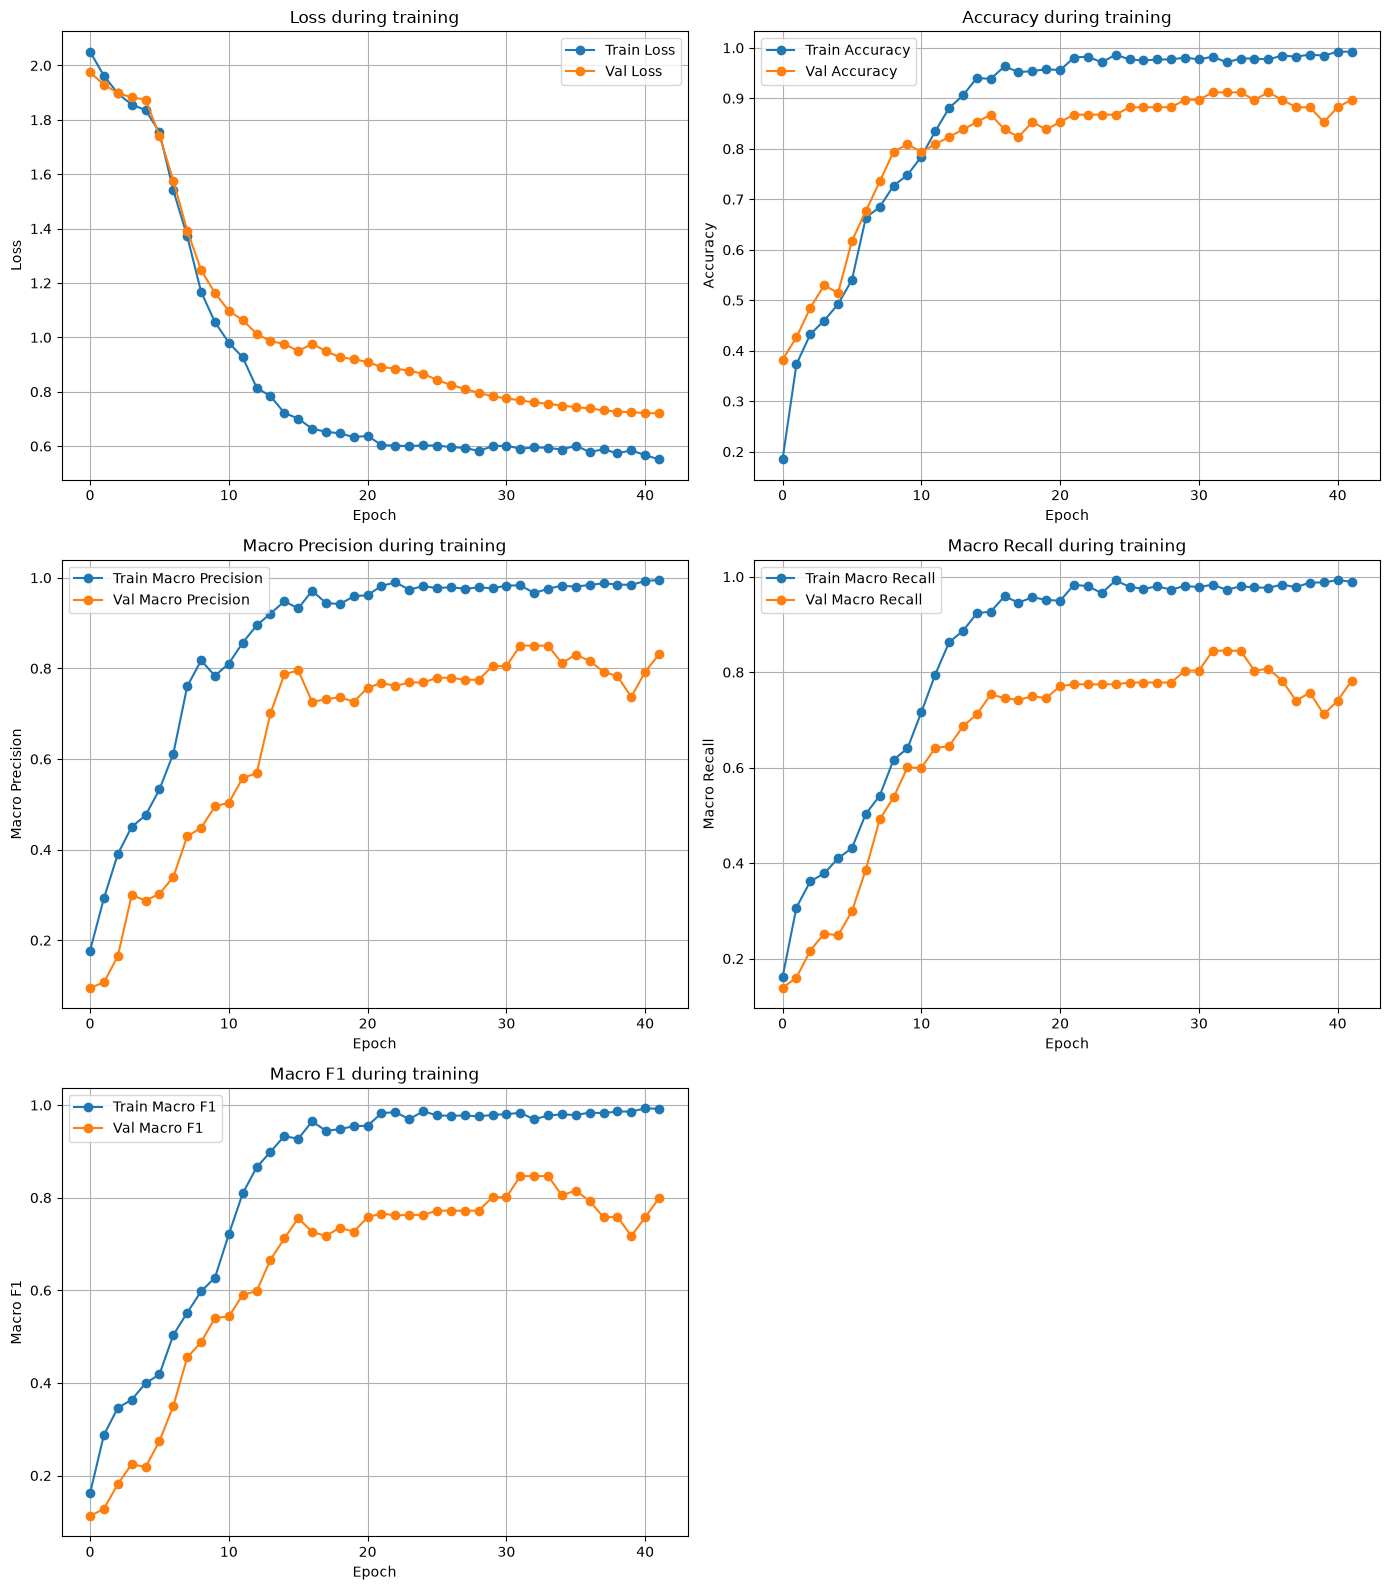

In [9]:
model_dir = Path("../../model/mobilenet_v3_large")
checkpoint_path = model_dir / "CKPlus_MobileNetV3Large_checkpoint.pth"
checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
epochs = range(0, len(checkpoint['train_acc_hist']))

plt.figure(figsize=(14, 16))

# ==========================================
# 1. LOSS
# ==========================================

plt.subplot(3, 2, 1)
plt.plot(epochs, checkpoint["train_loss_hist"], label="Train Loss", marker="o")
plt.plot(epochs, checkpoint["val_loss_hist"], label="Val Loss", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss during training")
plt.legend()
plt.grid(True)

# ==========================================
# 2. ACCURACY
# ==========================================

plt.subplot(3, 2, 2)
plt.plot(epochs, checkpoint["train_acc_hist"],label="Train Accuracy", marker="o")
plt.plot(epochs, checkpoint["val_acc_hist"], label="Val Accuracy", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy during training")
plt.legend()
plt.grid(True)

# ==========================================
# 3. MACRO PRECISION
# ==========================================

plt.subplot(3, 2, 3)
plt.plot(epochs, checkpoint["train_precision_hist"], label="Train Macro Precision", marker="o")
plt.plot(epochs, checkpoint["val_precision_hist"], label="Val Macro Precision", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Macro Precision")
plt.title("Macro Precision during training")
plt.legend()
plt.grid(True)

# ==========================================
# 4. MACRO RECALL
# ==========================================

plt.subplot(3, 2, 4)
plt.plot(epochs, checkpoint["train_recall_hist"], label="Train Macro Recall", marker="o")
plt.plot(epochs, checkpoint["val_recall_hist"], label="Val Macro Recall", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Macro Recall")
plt.title("Macro Recall during training")
plt.legend()
plt.grid(True)

# ==========================================
# 5. MACRO F1
# ==========================================

plt.subplot(3, 2, 5)
plt.plot(epochs, checkpoint["train_macro_f1_hist"], label="Train Macro F1", marker="o")
plt.plot(epochs, checkpoint["val_macro_f1_hist"], label="Val Macro F1", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("Macro F1 during training")
plt.legend()
plt.grid(True)


plt.tight_layout()
plt.show()

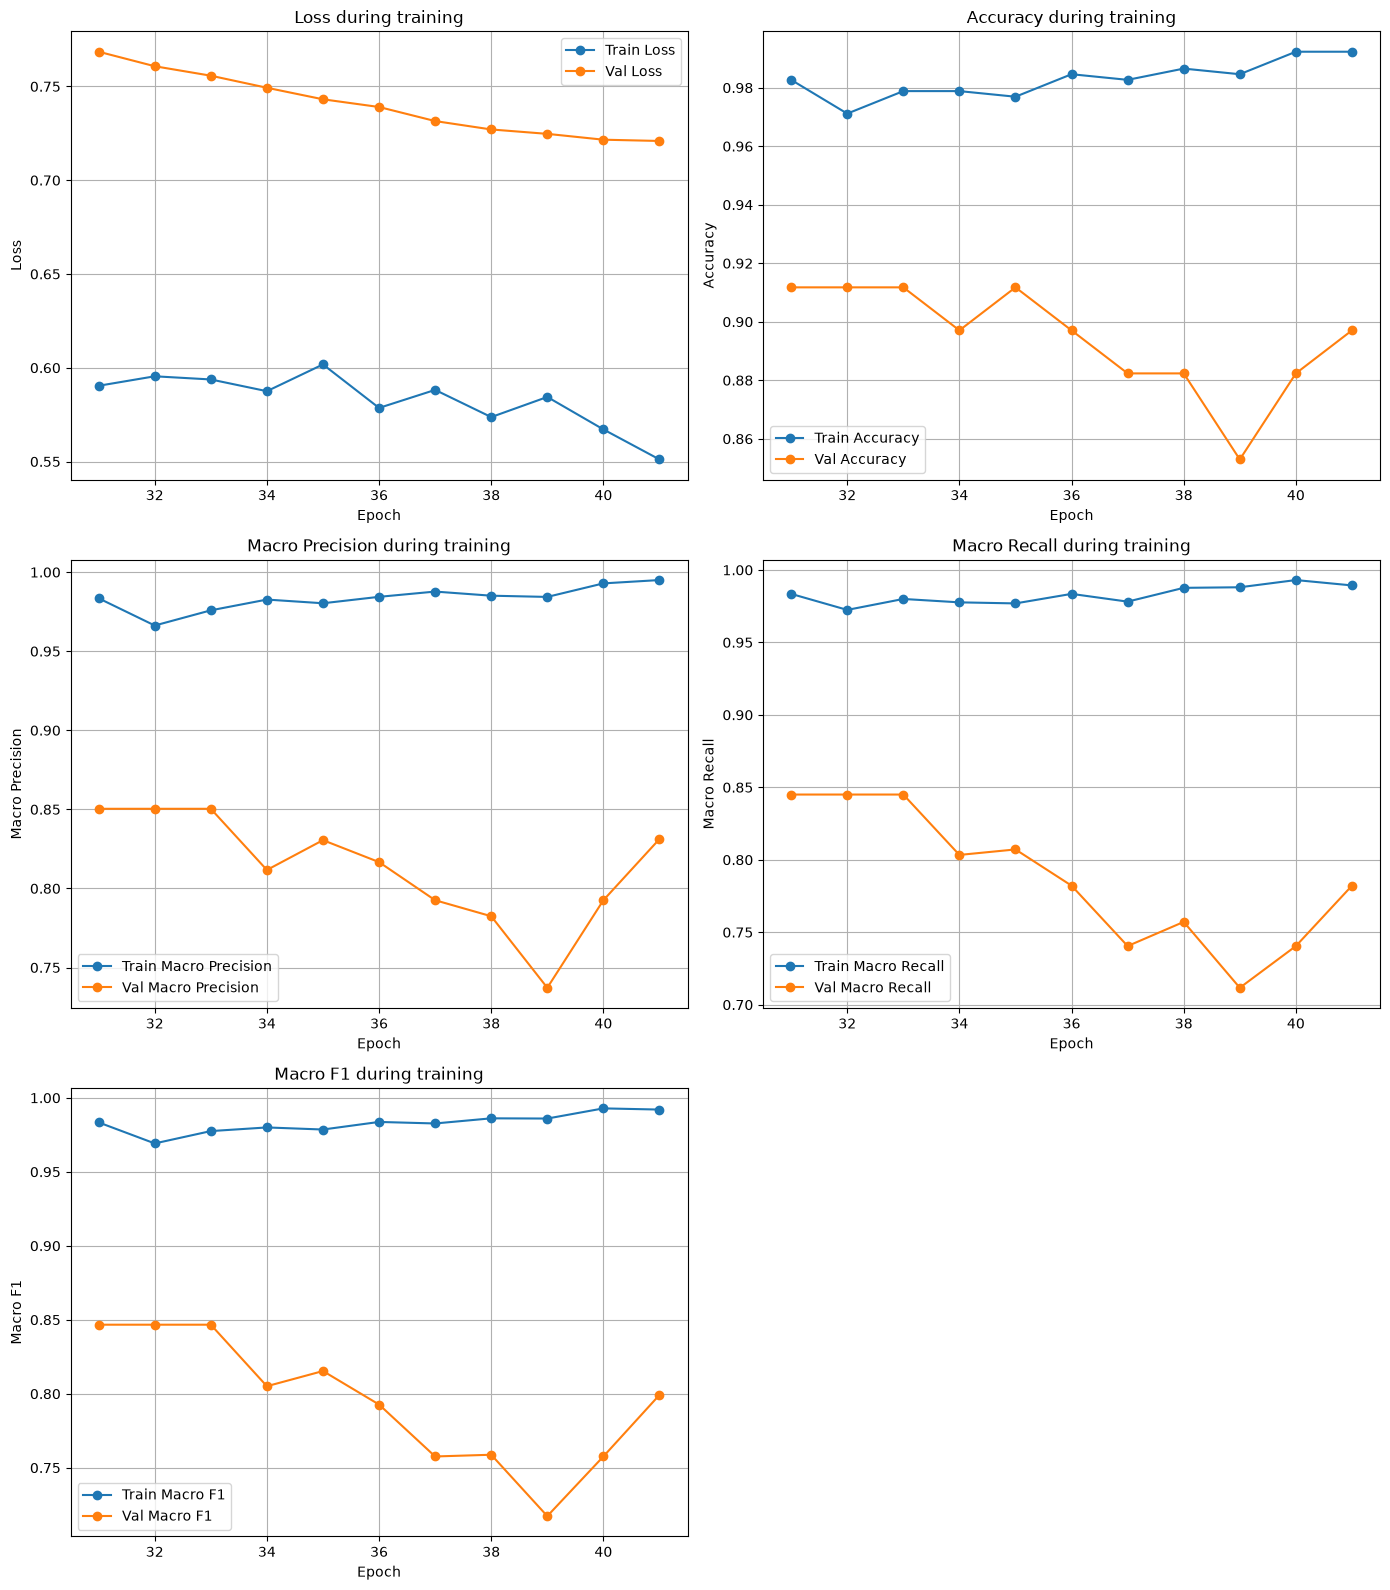

In [10]:
model_dir = Path("../../model/mobilenet_v3_large")
checkpoint_path = model_dir / "CKPlus_MobileNetV3Large_checkpoint.pth"
checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
distance = 11
epochs = range(checkpoint['epoch'] - distance + 1, checkpoint['epoch'] + 1)

plt.figure(figsize=(14, 16))

# ==========================================
# 1. LOSS
# ==========================================

plt.subplot(3, 2, 1)
plt.plot(epochs, checkpoint["train_loss_hist"][-distance:], label="Train Loss", marker="o")
plt.plot(epochs, checkpoint["val_loss_hist"][-distance:], label="Val Loss", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss during training")
plt.legend()
plt.grid(True)

# ==========================================
# 2. ACCURACY
# ==========================================

plt.subplot(3, 2, 2)
plt.plot(epochs, checkpoint["train_acc_hist"][-distance:], label="Train Accuracy", marker="o")
plt.plot(epochs, checkpoint["val_acc_hist"][-distance:], label="Val Accuracy", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy during training")
plt.legend()
plt.grid(True)

# ==========================================
# 3. MACRO PRECISION
# ==========================================

plt.subplot(3, 2, 3)
plt.plot(epochs, checkpoint["train_precision_hist"][-distance:], label="Train Macro Precision", marker="o")
plt.plot(epochs, checkpoint["val_precision_hist"][-distance:], label="Val Macro Precision", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Macro Precision")
plt.title("Macro Precision during training")
plt.legend()
plt.grid(True)

# ==========================================
# 4. MACRO RECALL
# ==========================================

plt.subplot(3, 2, 4)
plt.plot(epochs, checkpoint["train_recall_hist"][-distance:], label="Train Macro Recall", marker="o")
plt.plot(epochs, checkpoint["val_recall_hist"][-distance:], label="Val Macro Recall", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Macro Recall")
plt.title("Macro Recall during training")
plt.legend()
plt.grid(True)

# ==========================================
# 5. MACRO F1
# ==========================================

plt.subplot(3, 2, 5)
plt.plot(epochs, checkpoint["train_macro_f1_hist"][-distance:], label="Train Macro F1", marker="o")
plt.plot(epochs, checkpoint["val_macro_f1_hist"][-distance:], label="Val Macro F1", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("Macro F1 during training")
plt.legend()
plt.grid(True)


plt.tight_layout()
plt.show()

In [11]:
total_params = sum(p.numel() for p in model.parameters())
total_params_m = total_params / 1e6

dummy_input = torch.randn(1, 3, 224, 224).to(device)

flops, params = profile(model, inputs=(dummy_input,), verbose=False)

gflops = flops / 1e9

model_size_mb = os.path.getsize(best_weights_path) / (1024 ** 2)

print(f"Parameters: {total_params_m:.2f} M")
print(f"GFLOPs: {gflops:.2f}")
print(f"Model size: {model_size_mb:.2f} MB")
print(f"Training time: {training_time:.2f} seconds")

Parameters: 4.21 M
GFLOPs: 0.23
Model size: 16.28 MB
Training time: 79.06 seconds


In [12]:
model = CKPlus_MobileNetV3Large(num_class=8)
model.load_state_dict(torch.load("../../model/mobilenet_v3_large/CKPlus_MobileNetV3Large_best_weights.pth", map_location=device))
model.to(device)

CKPlus_MobileNetV3Large(
  (backbone): MobileNetV3(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (1): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
          )
        )
      )
      (2): InvertedResidual(
        (block): 

In [13]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch , y_batch in testloader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

In [14]:
accuracy = accuracy_score(all_labels, all_preds)

macro_precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)

macro_recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)

macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

print(f"Test Accuracy: {accuracy * 100:.2f}%")
print(f"Test Macro Precision: {macro_precision * 100:.2f}%")
print(f"Test Macro Recall: {macro_recall * 100:.2f}%")
print(f"Test Macro F1: {macro_f1 * 100:.2f}%")

Test Accuracy: 93.85%
Test Macro Precision: 89.50%
Test Macro Recall: 86.08%
Test Macro F1: 86.04%


In [15]:
class_names = test_dataset.classes

report = classification_report(all_labels, all_preds, target_names=class_names, digits=4, zero_division=0)

print(report)

              precision    recall  f1-score   support

           0     0.9697    0.9697    0.9697        33
           1     1.0000    0.7500    0.8571         4
           2     0.6667    1.0000    0.8000         2
           3     0.8571    1.0000    0.9231         6
           4     1.0000    0.5000    0.6667         2
           5     1.0000    1.0000    1.0000         7
           6     0.6667    0.6667    0.6667         3
           7     1.0000    1.0000    1.0000         8

    accuracy                         0.9385        65
   macro avg     0.8950    0.8608    0.8604        65
weighted avg     0.9458    0.9385    0.9369        65



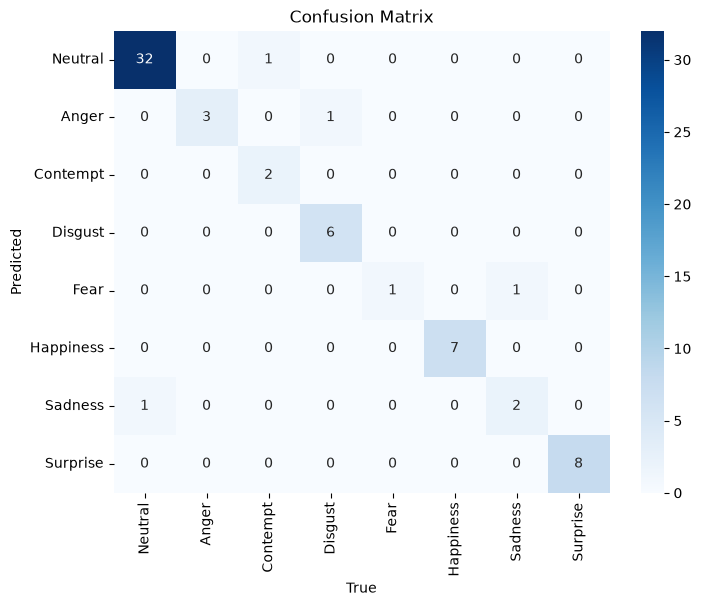

In [16]:
cm = confusion_matrix(all_labels, all_preds)

emotions = [
    "Neutral",    # 0
    "Anger",      # 1
    "Contempt",   # 2
    "Disgust",    # 3
    "Fear",       # 4
    "Happiness",  # 5
    "Sadness",    # 6
    "Surprise"    # 7
]

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=emotions, yticklabels=emotions, cmap='Blues')
plt.xlabel('True')
plt.ylabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

In [17]:
cm

array([[32,  0,  1,  0,  0,  0,  0,  0],
       [ 0,  3,  0,  1,  0,  0,  0,  0],
       [ 0,  0,  2,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  6,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  1,  0,  1,  0],
       [ 0,  0,  0,  0,  0,  7,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  2,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  8]])

In [18]:
results_path = Path("../../results")
results_path.mkdir(parents=True, exist_ok=True)
test_csv = results_path / "benchmark_results.csv"

columns = ["Model", "Accuracy", "Macro_Precision", "Macro_Recall", "Macro_F1", "Parameters_M", "GFLOPs", "Model_Size_MB", "Training_Time_Seconds"]

if not test_csv.exists():
    pd.DataFrame(columns=columns).to_csv(test_csv, index=False)

print(f"Results file: {test_csv}")

Results file: ../../results/benchmark_results.csv


In [19]:
test_row = {
    "Model": "MobileNetV3 Large",
    "Accuracy": accuracy * 100,
    "Macro_Precision": macro_precision * 100,
    "Macro_Recall": macro_recall * 100,
    "Macro_F1": macro_f1 * 100,
    "Parameters_M": total_params_m,
    "GFLOPs": gflops,
    "Model_Size_MB": model_size_mb,
    "Training_Time_Seconds": training_time
}

df_test = pd.read_csv(test_csv)

mask = df_test["Model"] == test_row["Model"]

if mask.any():
    for column, value in test_row.items():
        df_test.loc[mask, column] = value
else:
    df_test = pd.concat([df_test, pd.DataFrame([test_row])], ignore_index=True)

df_test.to_csv(test_csv, index=False)

In [20]:
df_test

,Model,Accuracy,Macro_Precision,Macro_Recall,Macro_F1,Parameters_M,GFLOPs,Model_Size_MB,Training_Time_Seconds
0,ResNet18,92.307692,92.976190,86.079545,85.803167,11.180616,1.823526,42.730479,67.559321
1,ResNet34,92.307692,89.123377,88.825758,87.923743,21.288776,3.678232,81.351665,67.453247
2,ResNet50,90.769231,90.277778,83.252165,82.715998,23.524424,4.131711,90.052487,113.384481
3,ResNet101,92.307692,88.151042,90.165043,87.390110,42.516552,7.864404,162.807292,163.726815
4,MobileNetV2,81.538462,68.597973,65.165043,63.711081,2.234120,0.326217,8.767772,72.368061
5,MobileNetV3 Small,73.846154,56.585149,65.584416,56.906524,1.526056,0.061462,5.960000,31.458744
6,MobileNetV3 Large,93.846154,89.502165,86.079545,86.040626,4.212280,0.233569,16.278279,79.058012


In [21]:
results_path = Path("../../results")
results_path.mkdir(parents=True, exist_ok=True)
train_val_csv = results_path / "train_val_results.csv"

columns_train_val = [
    "Model",
    "Best_Epoch",
    "Train_Loss",
    "Train_Accuracy",
    "Train_Macro_Precision",
    "Train_Macro_Recall",
    "Train_Macro_F1",
    "Val_Loss",
    "Val_Accuracy",
    "Val_Macro_Precision",
    "Val_Macro_Recall",
    "Val_Macro_F1"
]

if not train_val_csv.exists():
    pd.DataFrame(columns=columns_train_val).to_csv(train_val_csv, index=False)

print(f"Results file: {train_val_csv}")

Results file: ../../results/train_val_results.csv


In [22]:
best_epoch = checkpoint["best_epoch"]

train_val_row = {
    "Model": "MobileNetV3 Large",
    "Best_Epoch": best_epoch,
    "Train_Loss": checkpoint["train_loss_hist"][best_epoch],
    "Train_Accuracy": checkpoint["train_acc_hist"][best_epoch] * 100,
    "Train_Macro_Precision": checkpoint["train_precision_hist"][best_epoch] * 100,
    "Train_Macro_Recall": checkpoint["train_recall_hist"][best_epoch] * 100,
    "Train_Macro_F1": checkpoint["train_macro_f1_hist"][best_epoch] * 100,
    "Val_Loss": checkpoint["val_loss_hist"][best_epoch],
    "Val_Accuracy": checkpoint["val_acc_hist"][best_epoch] * 100,
    "Val_Macro_Precision": checkpoint["val_precision_hist"][best_epoch] * 100,
    "Val_Macro_Recall": checkpoint["val_recall_hist"][best_epoch] * 100,
    "Val_Macro_F1": checkpoint["val_macro_f1_hist"][best_epoch] * 100
}

df_train_val = pd.read_csv(train_val_csv)

mask = df_train_val["Model"] == train_val_row["Model"]

if mask.any():
    for column, value in train_val_row.items():
        df_train_val.loc[mask, column] = value
else:
    df_train_val = pd.concat([df_train_val, pd.DataFrame([train_val_row])], ignore_index=True)

df_train_val.to_csv(train_val_csv, index=False)

In [23]:
df_train_val

,Model,Best_Epoch,Train_Loss,Train_Accuracy,Train_Macro_Precision,Train_Macro_Recall,Train_Macro_F1,Val_Loss,Val_Accuracy,Val_Macro_Precision,Val_Macro_Recall,Val_Macro_F1
0,ResNet18,24,0.519855,99.807692,99.807692,99.907407,99.856632,0.682948,95.588235,96.819853,89.166667,91.933316
1,ResNet34,14,0.527797,98.653846,98.009898,98.157534,98.082490,0.639438,95.588235,95.119048,90.833333,92.340686
2,ResNet50,19,0.532955,99.038462,98.861059,98.946501,98.901184,0.726188,91.176471,87.708333,83.095238,83.623188
3,ResNet101,18,0.524682,98.461538,98.732353,98.122996,98.420895,0.612666,94.117647,94.375000,89.047619,90.298562
4,MobileNetV2,22,0.795979,89.038462,90.032953,85.132591,87.158413,0.852788,86.764706,80.902778,74.383117,74.959588
5,MobileNetV3 Small,13,0.947601,85.769231,88.617055,80.354483,81.488891,1.271172,70.588235,49.541095,58.360390,52.291667
6,MobileNetV3 Large,31,0.590414,98.269231,98.347614,98.347973,98.340054,0.768515,91.176471,85.037879,84.502165,84.668446
